In [598]:
import pandas as pd
import json
import glob
import re
import plotly.express as px
import plotly.graph_objects as go

In [599]:
path_list = [path for path in glob.glob("./data/*/*")] # Define list of all possible file paths
for i in path_list: # for each path in list
    with open(i) as json_data: # read in json
        data = json.load(json_data) 
        current_df = pd.DataFrame(data["jobs_results"]) # save json as dataframe
        current_df =current_df.rename(columns = {"title":"job_title"})
        # there is json within a column, get that into separate columns
        exploded =current_df.explode("job_highlights")
        df1 = pd.concat([exploded["job_id"].reset_index(drop=True), pd.json_normalize(exploded["job_highlights"])], axis=1)
        df1 = df1.pivot(columns="title", index = "job_id")
        df1 = df1["items"]
        df1 = df1.reset_index()
        df1 = df1.rename_axis("index")
        current_df = current_df.merge(df1, on = "job_id").drop("job_highlights", axis = 1)
    # if first iteration create dataframe df
    if i == path_list[0]:
            df = current_df
    # if not first iteration, append dataframe to df
    else:
        df = pd.concat([df, current_df])
# drop related links variable
df = df.drop(columns=["related_links"], axis = 1)
# get relevant variables from detected extensions
df["schedule_type"] = df["detected_extensions"].apply(lambda x: x.get("schedule_type"))
df["work_from_home"] = df["detected_extensions"].apply(lambda x: x.get("work_from_home"))
df["work_from_home"][df["work_from_home"]!= True] = False
df["salary"] = df["detected_extensions"].apply(lambda x: x.get("salary"))
df = df.drop("detected_extensions", axis = 1)
df = df.drop(df.columns[7], axis = 1)
# drop duplicates where a duplicate is defined as having the same title, company name, location, schedule type, and description
df = df.drop_duplicates(subset=["job_title", "company_name", "location", "schedule_type", "description"], keep="first")

In [600]:

# convert all job titles to lowercase
df['job_title'] = df['job_title'].str.lower()

# remove unnecessary words from the job title
remove_words = ['senior', 'junior', 'manager']
pattern = '|'.join(remove_words)
df['job_title'] = df['job_title'].apply(lambda x: re.sub(pattern, '', x))

# define regular expressions to extract the main job title category
data_scientist_regex = re.compile(r'data\s*scientist')
data_analyst_regex = re.compile(r'data\s*analyst')
machine_learning_regex = re.compile(r'machine\s*learning')
cloud_engineer_regex = re.compile(r'cloud\s*engineer')
blockchain_regex = re.compile(r'blockchain\s*engineer')
deep_learning_regex = re.compile(r'deep\s*learning')
# create a function to apply the regular expressions and return the cleaned job title category
def clean_job_title(job_title):
    if data_scientist_regex.search(job_title):
        return 'Data Scientist'
    elif data_analyst_regex.search(job_title):
        return 'Data Analyst'
    elif machine_learning_regex.search(job_title):
        return 'Machine Learning Engineer'
    elif cloud_engineer_regex.search(job_title):
        return 'Cloud Software Engineer'
    elif blockchain_regex.search(job_title):
        return "Blockchain Engineer"
    elif deep_learning_regex.search(job_title):
        return "Deep Learning Engineer"
    else:
        return job_title

# create a new column with the cleaned job title category
df['clean_job_title'] = df['job_title'].apply(clean_job_title)

# clean locations to remove +1 others
df["location"] = df["location"].str.strip()
df["location"][df["location"]=="New York, NY   (+2 others)"] = "New York, NY"
df["location"][df["location"]=="United States  (+1 other)"] = "United States"
df["location"][df["location"]=="Missouri  (+1 other)"] = "Missouri"
df["location"][df["location"]=="Texas   (+5 others)"] = "Texas"
df["location"][df["location"]=="California  (+1 other)"] = "California"
df["location"][df["location"]=="Lexington, MA  (+1 other)"] = "Lexington, MA"
df["location"][df["location"]=="United States   (+21 others)"] = "United States"
df["location"][df["location"]=="United States   (+26 others)"] = "United States"
df["location"][df["location"]=="Boston, MA  (+1 other)"] = "Boston, MA"
df["location"][df["location"]=="Anywhere"] = "United States"



In [601]:
### Get Required Degree
# define a function to join the list of strings into a single string
def join_strings(lst):
    if isinstance(lst, list):
        return ' '.join(filter(None, lst))
    else:
        return ''

# join all the strings in each list into a single string
df["Qualifications"] = df["Qualifications"].apply(join_strings)
df["Qualifications"] = df["Qualifications"].str.lower()
df["Qualifications"] = df["Qualifications"].str.replace(".", "")

# Degree in Qualifications



/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/3156811504.py:12: FutureWarning:

The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.



In [602]:
pattern = r'\b(bachelor(\'s)?|bs|ba)s?\b'
# create a new column "has_bachelor" that contains True if any of the terms in the pattern are in the "qualifications" column and False otherwise
df['bachelor'] = df["Qualifications"].str.contains(pattern, case=False, na=False).fillna(False)
# Masters
pattern = r'\b(master(\'s)?|ms)s?\b'
# create a new column "has_master" that contains True if any of the terms in the pattern are in the "qualifications" column and False otherwise
df['masters'] = df['Qualifications'].str.contains(pattern, case=False, na=False).fillna(False)
# create a regular expression pattern to match "PhD", "Ph.D.", "doctorate", or "dr", including variations with dots or dashes
pattern = r'\b(phd|ph\.d\.|doctorate|dr)\b'
# create a new column "has_phd" that contains True if any of the terms in the pattern are in the "text" column and False otherwise
df['phd'] = df['Qualifications'].str.contains(pattern, case=False, na=False).fillna(False)

# minimum education requirement
df["minimum_education"] = None
df["minimum_education"][df["bachelor"]==True] = "Bachelor"
df["minimum_education"][(df['bachelor'] == False) & (df['masters'] == True)] = "Master"
df["minimum_education"][(df['bachelor'] == False) & (df['masters'] == False) & (df["phd"] == True)] = "PhD"
df= df.drop(columns = ["bachelor", "masters", "phd"], axis = 1)

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/4293936144.py:3: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/4293936144.py:7: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/4293936144.py:11: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/4293936144.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/m0/y_433zr10m79zw6c

In [603]:
# Find required skils
df["Responsibilities"] = df["Responsibilities"].apply(join_strings)
df["Responsibilities"] = df["Responsibilities"].str.lower()
df["Responsibilities"] = df["Responsibilities"].str.replace(".", "")
# python
df['python'] = (df["Qualifications"].str.contains("python", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("python", case=False, na=False).fillna(False))

# sql
df['sql'] = (df["Qualifications"].str.contains("sql", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("sql", case=False, na=False).fillna(False))

# machine learning
df['machine_learning'] = (df["Qualifications"].str.contains("machine learning", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("machine learning", case=False, na=False).fillna(False))

# communication
df['communication'] = (df["Qualifications"].str.contains("communication", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("communication", case=False, na=False).fillna(False))

# software engineering
df['software_engineering'] = (df["Qualifications"].str.contains("software engineering", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("software engineering", case=False, na=False).fillna(False))

# deep learning
df['deep_learning'] = (df["Qualifications"].str.contains("deep learning", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("deep learning", case=False, na=False).fillna(False))

# language processing
df['language_processing'] = (df["Qualifications"].str.contains("language processing", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("language processing", case=False, na=False).fillna(False))

# pytorch
df['pytorch'] = (df["Qualifications"].str.contains("pytorch", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("pytorch", case=False, na=False).fillna(False))

# computer vision
df['computer_vision'] = (df["Qualifications"].str.contains("computer vision", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("computer vision", case=False, na=False).fillna(False))

# tableau
df['tableau'] = (df["Qualifications"].str.contains("tableau", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("tableau", case=False, na=False).fillna(False))

# management
df['management'] = (df["Qualifications"].str.contains("management", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("management", case=False, na=False).fillna(False))

# tensorflow
df['tensorflow'] = (df["Qualifications"].str.contains("tensorflow", case=False, na=False).fillna(False) | df["Responsibilities"].str.contains("tensorflow", case=False, na=False).fillna(False))



/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/2999354327.py:4: FutureWarning:

The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.



In [ ]:
from folium.plugins import HeatMap
# Create a new column for location coordinates
df["location_coord"] = df["location"].apply(geolocator.geocode).apply(lambda x: (x.latitude, x.longitude) if x else None)

# Filter out rows where geocoding failed
df = df.dropna(subset=["location_coord"])

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_28985/3989791410.py:2: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



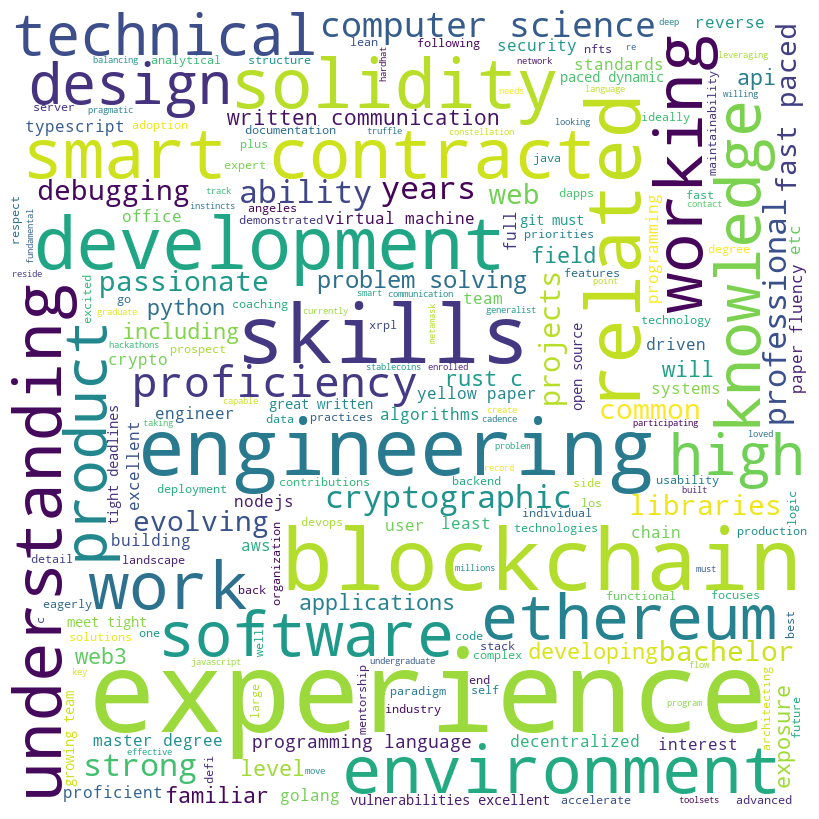

In [553]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

# create a sample DataFrame
df1 = df[df["clean_job_title"]=="Blockchain Engineer"]
# concatenate all the text in the column into a single string
text = ' '.join(df1['Qualifications'].values.tolist())

# create a set of stopwords to exclude from the word cloud
stopwords = set(STOPWORDS)

# create a WordCloud object with the stopwords set and other parameters
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stopwords)

# generate the word cloud from the text
wordcloud.generate(text)

# visualize the word cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
